# Capítulo 2 — Reconocer tipos de problemas de Machine Learning

En el capítulo vimos que no todos los problemas de Machine Learning son iguales. Algunos buscan predecir una categoría, otros estimar un valor numérico, otros descubrir grupos y otros detectar casos inusuales.

Antes de elegir un modelo, necesitamos entender qué tipo de problema tenemos. Esa decisión depende de dos preguntas iniciales:

¿Tenemos una respuesta conocida para cada ejemplo?

¿Qué queremos obtener como resultado?

En este cuaderno vamos a trabajar con ejemplos pequeños y visuales para reconocer distintos tipos de problemas. Todavía no vamos a entrenar modelos. El objetivo es aprender a formular el problema antes de pensar en algoritmos.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- diferenciar datos etiquetados y no etiquetados;
- reconocer cuándo un problema es supervisado o no supervisado;
- distinguir problemas de clasificación, regresión, agrupamiento y detección de anomalías;
- interpretar qué tipo de salida se espera en cada caso;
- comprender por qué no todos los modelos sirven para todos los problemas.

## Empezar por la pregunta

Cuando trabajamos con Machine Learning, una de las primeras decisiones no es elegir un algoritmo, sino entender qué pregunta queremos responder.

Por ejemplo, no es lo mismo preguntar:

“¿Este correo es spam o no?”

que preguntar:

“¿Cuál será el precio aproximado de esta vivienda?”

En el primer caso esperamos una categoría. En el segundo, un número. Esa diferencia ya nos indica que estamos frente a tipos de problemas distintos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
situaciones = pd.DataFrame({
    "situacion": [
        "Detectar si un correo es spam",
        "Estimar el precio de una vivienda",
        "Agrupar clientes con comportamientos parecidos",
        "Detectar consumos eléctricos inusuales",
        "Predecir si un estudiante aprueba o no",
        "Estimar la duración de un viaje"
    ],
    "tenemos_respuesta_conocida": [
        "Sí",
        "Sí",
        "No",
        "No necesariamente",
        "Sí",
        "Sí"
    ],
    "salida_esperada": [
        "Categoría",
        "Valor numérico",
        "Grupos sugeridos",
        "Caso habitual o inusual",
        "Categoría",
        "Valor numérico"
    ],
    "tipo_de_problema": [
        "Clasificación",
        "Regresión",
        "Agrupamiento",
        "Detección de anomalías",
        "Clasificación",
        "Regresión"
    ]
})

situaciones

,situacion,tenemos_respuesta_conocida,salida_esperada,tipo_de_problema
0,Detectar si un correo es spam,Sí,Categoría,Clasificación
1,Estimar el precio de una vivienda,Sí,Valor numérico,Regresión
2,Agrupar clientes con comportamientos parecidos,No,Grupos sugeridos,Agrupamiento
3,Detectar consumos eléctricos inusuales,No necesariamente,Caso habitual o inusual,Detección de anomalías
4,Predecir si un estudiante aprueba o no,Sí,Categoría,Clasificación
5,Estimar la duración de un viaje,Sí,Valor numérico,Regresión


La tabla anterior resume varias situaciones posibles.

En algunos casos tenemos ejemplos con una respuesta conocida. Por ejemplo, podemos tener correos ya identificados como spam o no spam, o viviendas cuyo precio ya conocemos. Estos casos pertenecen al aprendizaje supervisado.

En otros casos no tenemos una respuesta correcta previa. Por ejemplo, si queremos agrupar clientes con comportamientos parecidos, no partimos necesariamente de una etiqueta ya definida. En ese caso buscamos descubrir una estructura en los datos. Este tipo de problema se asocia al aprendizaje no supervisado.

Una idea importante es que el tipo de problema depende de la pregunta. Antes de elegir herramientas o modelos, necesitamos entender qué queremos predecir, estimar o descubrir.

## Clasificación: predecir una categoría

En un problema de clasificación, la salida esperada es una categoría.

Por ejemplo, podríamos querer predecir si un estudiante aprobará o no un examen a partir de algunas variables, como la cantidad de horas de estudio y la asistencia a clase.

En este ejemplo, la variable que queremos predecir tiene dos valores posibles: `Aprueba` o `No aprueba`.

In [3]:
datos_clasificacion = pd.DataFrame({
    "horas_estudio": [1, 2, 2, 3, 4, 4, 5, 6, 6, 7, 8, 9],
    "asistencia": [40, 50, 55, 60, 65, 70, 72, 75, 82, 85, 90, 95],
    "resultado": [
        "No aprueba", "No aprueba", "No aprueba", "No aprueba",
        "Aprueba", "No aprueba", "Aprueba", "Aprueba",
        "Aprueba", "Aprueba", "Aprueba", "Aprueba"
    ]
})

datos_clasificacion

,horas_estudio,asistencia,resultado
0,1,40,No aprueba
1,2,50,No aprueba
2,2,55,No aprueba
3,3,60,No aprueba
4,4,65,Aprueba
5,4,70,No aprueba
6,5,72,Aprueba
7,6,75,Aprueba
8,6,82,Aprueba
9,7,85,Aprueba


En este ejemplo, cada fila representa un estudiante.

Las columnas `horas_estudio` y `asistencia` describen características del estudiante. La columna `resultado` contiene la respuesta conocida para cada caso.

Como la respuesta es una categoría, estamos frente a un problema de clasificación.

Además, como ya conocemos el resultado de cada estudiante en los datos históricos, este ejemplo pertenece al aprendizaje supervisado.

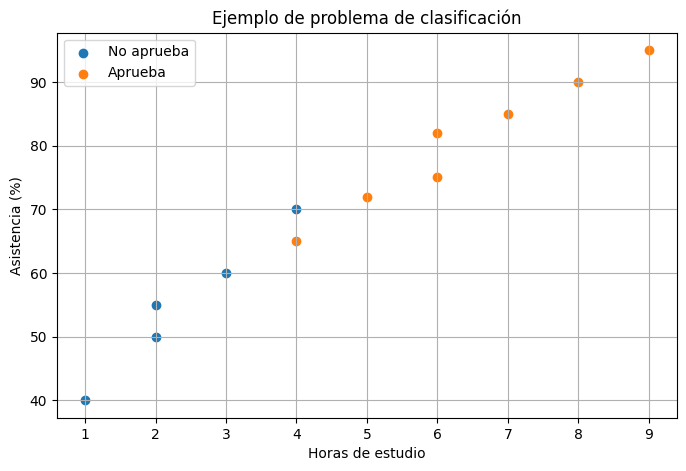

In [4]:
plt.figure(figsize=(8, 5))

for resultado in datos_clasificacion["resultado"].unique():
    datos_filtrados = datos_clasificacion[datos_clasificacion["resultado"] == resultado]

    plt.scatter(
        datos_filtrados["horas_estudio"],
        datos_filtrados["asistencia"],
        label=resultado
    )

plt.title("Ejemplo de problema de clasificación")
plt.xlabel("Horas de estudio")
plt.ylabel("Asistencia (%)")
plt.grid(True)
plt.legend()

plt.show()

El gráfico muestra los estudiantes como puntos. La posición de cada punto depende de sus horas de estudio y su asistencia, mientras que la categoría indica si aprobó o no aprobó.

En un problema de clasificación, el objetivo sería aprender a separar o distinguir categorías. En este caso, ante un estudiante nuevo, nos interesaría responder algo como:

“¿Este estudiante aprobará o no aprobará?”

La respuesta esperada no es un número cualquiera, sino una clase.

## Regresión: predecir un valor numérico

En un problema de regresión, la salida esperada es un valor numérico.

Por ejemplo, podríamos querer estimar la duración de un viaje a partir de la distancia recorrida. En este caso, no buscamos una categoría como `Largo` o `Corto`, sino un número: la cantidad aproximada de minutos que durará el viaje.

In [5]:
datos_regresion = pd.DataFrame({
    "distancia_km": [1, 2, 3, 5, 7, 8, 10, 12, 15, 18, 20, 25],
    "duracion_min": [5, 8, 11, 16, 22, 25, 31, 36, 45, 54, 61, 75]
})

datos_regresion

,distancia_km,duracion_min
0,1,5
1,2,8
2,3,11
3,5,16
4,7,22
5,8,25
6,10,31
7,12,36
8,15,45
9,18,54


En este segundo ejemplo, cada fila representa un viaje.

La columna `distancia_km` describe una característica del viaje. La columna `duracion_min` contiene la duración observada en minutos.

Como la respuesta que queremos estimar es un número, estamos frente a un problema de regresión.

También es un caso de aprendizaje supervisado, porque contamos con ejemplos históricos donde ya conocemos la respuesta: para cada distancia registrada, tenemos una duración observada.

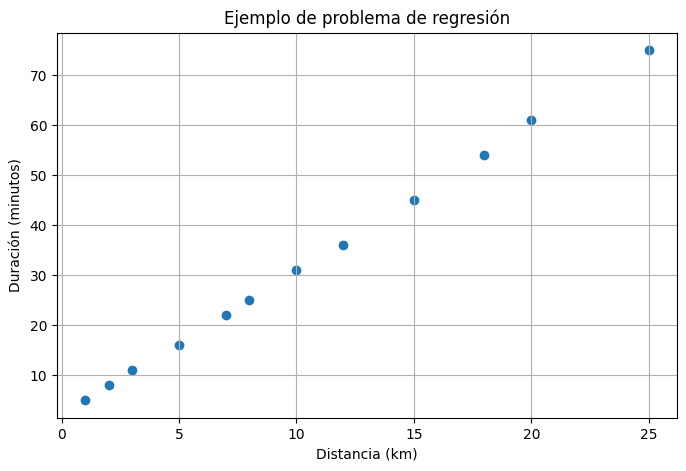

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    datos_regresion["distancia_km"],
    datos_regresion["duracion_min"]
)

plt.title("Ejemplo de problema de regresión")
plt.xlabel("Distancia (km)")
plt.ylabel("Duración (minutos)")
plt.grid(True)

plt.show()

El gráfico muestra una relación ascendente entre distancia y duración: en general, los viajes más largos duran más minutos.

A diferencia del ejemplo anterior, acá no queremos asignar una categoría como `Aprueba` o `No aprueba`. Queremos estimar un valor numérico.

Por eso, aunque clasificación y regresión pueden usar datos históricos con respuestas conocidas, se diferencian por el tipo de salida esperada:

en clasificación, la salida es una categoría;

en regresión, la salida es un número.

In [7]:
comparacion_supervisados = pd.DataFrame({
    "tipo_de_problema": ["Clasificación", "Regresión"],
    "pregunta_ejemplo": [
        "¿El estudiante aprueba o no aprueba?",
        "¿Cuánto durará el viaje?"
    ],
    "salida_esperada": [
        "Categoría",
        "Valor numérico"
    ],
    "ejemplo_de_respuesta": [
        "Aprueba",
        "45 minutos"
    ]
})

comparacion_supervisados

,tipo_de_problema,pregunta_ejemplo,salida_esperada,ejemplo_de_respuesta
0,Clasificación,¿El estudiante aprueba o no aprueba?,Categoría,Aprueba
1,Regresión,¿Cuánto durará el viaje?,Valor numérico,45 minutos


La comparación anterior muestra que clasificación y regresión pueden parecerse en algo: en ambos casos tenemos datos históricos con una respuesta conocida.

La diferencia está en el tipo de respuesta que queremos predecir.

Si queremos predecir una categoría, hablamos de clasificación.

Si queremos predecir un valor numérico, hablamos de regresión.

Esta distinción es importante porque condiciona todo lo que viene después: qué modelo podríamos usar, cómo interpretamos sus resultados y qué métricas serían adecuadas para evaluarlo.

## Aprendizaje no supervisado: buscar estructura sin una respuesta conocida

En los ejemplos anteriores teníamos una respuesta conocida para cada fila.

En clasificación, sabíamos si cada estudiante había aprobado o no. En regresión, sabíamos cuánto había durado cada viaje.

Pero a veces no tenemos una columna con la respuesta correcta. En esos casos, el objetivo no es predecir una etiqueta ya conocida, sino explorar los datos para descubrir alguna estructura.

## Agrupamiento: encontrar casos parecidos

Supongamos que tenemos datos de clientes de una tienda. Para cada cliente conocemos cuántas compras realizó en el último año y cuánto gastó en total.

No tenemos una etiqueta previa que diga a qué grupo pertenece cada cliente. Sin embargo, podríamos querer observar si aparecen perfiles parecidos.

In [8]:
datos_clientes = pd.DataFrame({
    "compras_anuales": [2, 3, 4, 3, 5, 12, 14, 15, 13, 16, 6, 7],
    "gasto_anual": [80, 120, 150, 110, 170, 700, 760, 810, 740, 850, 300, 330]
})

datos_clientes

,compras_anuales,gasto_anual
0,2,80
1,3,120
2,4,150
3,3,110
4,5,170
5,12,700
6,14,760
7,15,810
8,13,740
9,16,850


En este dataset no tenemos una columna objetivo.

Cada fila representa un cliente, y las columnas disponibles describen su comportamiento de compra. Sabemos cuántas compras realizó cada cliente y cuánto gastó en el año, pero no tenemos una etiqueta previa que indique a qué grupo pertenece.

Por eso, este ejemplo no es supervisado. No estamos intentando aprender a partir de respuestas conocidas, sino explorar si los datos sugieren algún tipo de agrupamiento.

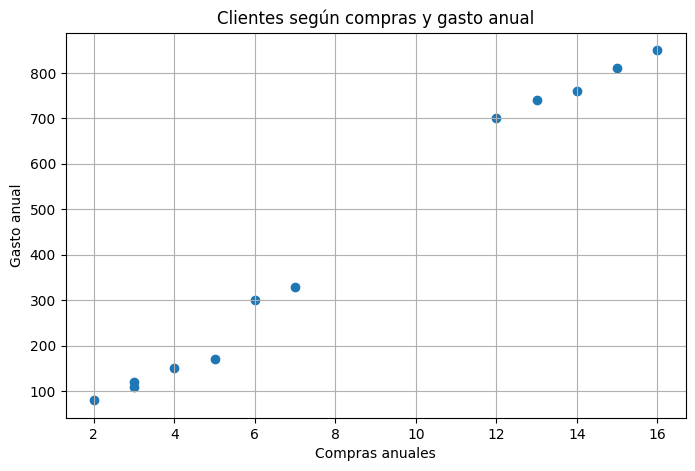

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    datos_clientes["compras_anuales"],
    datos_clientes["gasto_anual"]
)

plt.title("Clientes según compras y gasto anual")
plt.xlabel("Compras anuales")
plt.ylabel("Gasto anual")
plt.grid(True)

plt.show()

En el gráfico no usamos colores para representar grupos conocidos, porque en este dataset no tenemos una etiqueta previa.

Aun así, visualmente podríamos sospechar que existen perfiles distintos de clientes. Algunos compran poco y gastan poco, otros compran mucho y gastan mucho, y algunos quedan en una zona intermedia.

Esto es diferente de la clasificación. En clasificación, las categorías ya estaban en los datos y queríamos aprender a predecirlas. En agrupamiento, las categorías no están dadas de antemano: buscamos descubrir grupos posibles a partir de la estructura de los datos.

Para visualizar mejor la idea, podemos agregar una clasificación manual muy simple de los clientes según su comportamiento.

Esto no es todavía un modelo de Machine Learning. Es solo una forma de colorear el gráfico para representar una posible interpretación humana de los grupos que parecen aparecer.

In [10]:
def describir_cliente(fila):
    if fila["compras_anuales"] <= 5:
        return "Bajo movimiento"
    elif fila["compras_anuales"] <= 8:
        return "Movimiento medio"
    else:
        return "Alto movimiento"

datos_clientes["perfil_observado"] = datos_clientes.apply(describir_cliente, axis=1)

datos_clientes

,compras_anuales,gasto_anual,perfil_observado
0,2,80,Bajo movimiento
1,3,120,Bajo movimiento
2,4,150,Bajo movimiento
3,3,110,Bajo movimiento
4,5,170,Bajo movimiento
5,12,700,Alto movimiento
6,14,760,Alto movimiento
7,15,810,Alto movimiento
8,13,740,Alto movimiento
9,16,850,Alto movimiento


Ahora el DataFrame tiene una columna nueva llamada `perfil_observado`.

Esa columna no estaba en los datos originales. La creamos manualmente a partir de una regla sencilla basada en la cantidad de compras anuales.

Esto nos sirve para visualizar una posible interpretación de los grupos, pero no debe confundirse con un proceso automático de agrupamiento. Más adelante veremos algoritmos que pueden buscar grupos sin que tengamos que definirlos manualmente.

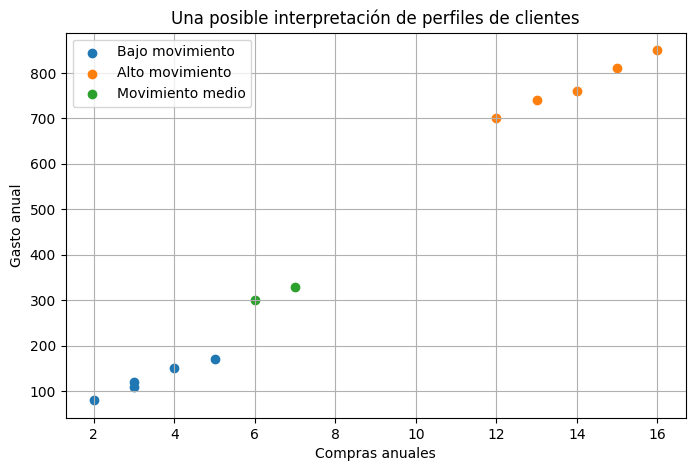

In [11]:
plt.figure(figsize=(8, 5))

for perfil in datos_clientes["perfil_observado"].unique():
    datos_filtrados = datos_clientes[datos_clientes["perfil_observado"] == perfil]

    plt.scatter(
        datos_filtrados["compras_anuales"],
        datos_filtrados["gasto_anual"],
        label=perfil
    )

plt.title("Una posible interpretación de perfiles de clientes")
plt.xlabel("Compras anuales")
plt.ylabel("Gasto anual")
plt.grid(True)
plt.legend()

plt.show()

El gráfico coloreado ayuda a visualizar una posible separación entre clientes de bajo, medio y alto movimiento.

Pero es importante recordar cómo obtuvimos esos grupos: los definimos manualmente con una regla sencilla. En un problema real de agrupamiento, no siempre sabremos de antemano dónde conviene trazar esas separaciones.

El aprendizaje no supervisado intenta justamente eso: encontrar estructura en datos que no vienen con una respuesta conocida.

## Detección de anomalías: encontrar casos inusuales

Otro tipo de problema consiste en detectar casos que se alejan mucho del comportamiento habitual.

Por ejemplo, podríamos tener registros de consumo eléctrico diario de una vivienda. La mayoría de los días el consumo puede estar dentro de un rango esperable, pero algunos días podrían mostrar valores muy altos o muy bajos.

Esos casos no necesariamente son errores. Pueden indicar una situación especial, una falla de medición o un evento que conviene revisar.

In [12]:
datos_consumo = pd.DataFrame({
    "dia": list(range(1, 16)),
    "consumo_kwh": [9.5, 10.2, 9.8, 10.5, 11.0, 10.1, 9.7, 10.4, 35.0, 9.9, 10.3, 10.0, 8.8, 10.6, 3.0]
})

datos_consumo

,dia,consumo_kwh
0,1,9.5
1,2,10.2
2,3,9.8
3,4,10.5
4,5,11.0
5,6,10.1
6,7,9.7
7,8,10.4
8,9,35.0
9,10,9.9


En este DataFrame, cada fila representa el consumo eléctrico de un día.

La mayoría de los valores están cerca de 10 kWh. Sin embargo, hay dos días que parecen diferentes al resto: el día 9 tiene un consumo mucho más alto y el día 15 tiene un consumo mucho más bajo.

Esos casos podrían considerarse inusuales. En un problema real, habría que investigarlos antes de decidir qué significan.

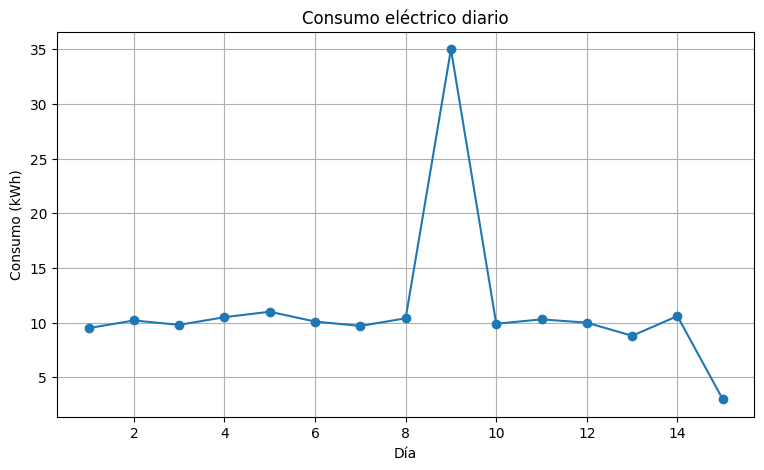

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    datos_consumo["dia"],
    datos_consumo["consumo_kwh"],
    marker="o"
)

plt.title("Consumo eléctrico diario")
plt.xlabel("Día")
plt.ylabel("Consumo (kWh)")
plt.grid(True)

plt.show()

El gráfico permite identificar rápidamente dos días que se alejan del comportamiento habitual.

El día 9 muestra un consumo mucho más alto que el resto. El día 15 muestra un consumo mucho más bajo.

En un problema de detección de anomalías, el objetivo no siempre es predecir una categoría o estimar un número. Muchas veces buscamos detectar casos que merecen una revisión especial.

Una anomalía no siempre es un error. Puede ser un dato mal cargado, una falla de medición, un evento excepcional o una situación real que necesita investigarse.

Para visualizar mejor los casos inusuales, vamos a crear una columna que marque los días cuyo consumo parece alejarse mucho del comportamiento habitual.

La regla que usaremos es simple: consideraremos como `Revisar` los consumos menores a 5 kWh o mayores a 20 kWh.

Esta regla no es un modelo. Es solo una forma manual de señalar valores que, en este ejemplo, llaman la atención.

In [14]:
datos_consumo["estado"] = datos_consumo["consumo_kwh"].apply(
    lambda consumo: "Revisar" if consumo < 5 or consumo > 20 else "Habitual"
)

datos_consumo

,dia,consumo_kwh,estado
0,1,9.5,Habitual
1,2,10.2,Habitual
2,3,9.8,Habitual
3,4,10.5,Habitual
4,5,11.0,Habitual
5,6,10.1,Habitual
6,7,9.7,Habitual
7,8,10.4,Habitual
8,9,35.0,Revisar
9,10,9.9,Habitual


La nueva columna `estado` separa los consumos habituales de los casos que decidimos revisar.

En este ejemplo, los días 9 y 15 quedaron marcados como `Revisar`, porque sus valores están muy lejos del rango más frecuente.

Esta decisión se tomó con una regla simple, definida manualmente. En problemas reales, detectar anomalías puede ser mucho más complejo, especialmente cuando hay muchas variables o cuando el comportamiento normal cambia con el tiempo.

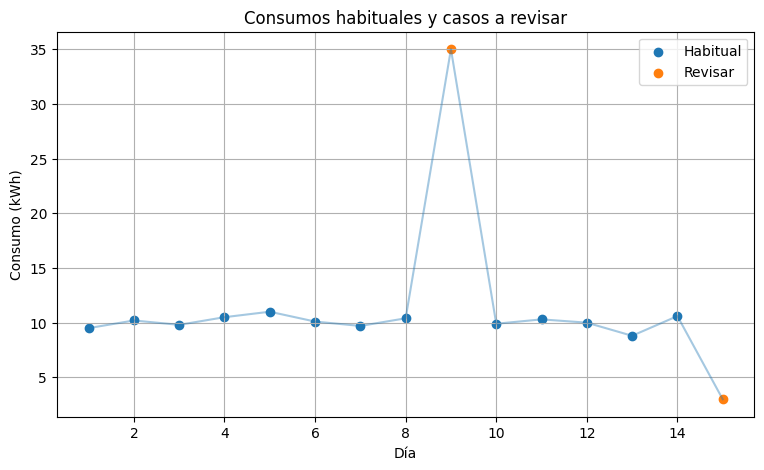

In [15]:
plt.figure(figsize=(9, 5))

for estado in datos_consumo["estado"].unique():
    datos_filtrados = datos_consumo[datos_consumo["estado"] == estado]

    plt.scatter(
        datos_filtrados["dia"],
        datos_filtrados["consumo_kwh"],
        label=estado
    )

plt.plot(
    datos_consumo["dia"],
    datos_consumo["consumo_kwh"],
    alpha=0.4
)

plt.title("Consumos habituales y casos a revisar")
plt.xlabel("Día")
plt.ylabel("Consumo (kWh)")
plt.grid(True)
plt.legend()

plt.show()

El gráfico permite distinguir visualmente los consumos habituales de los casos marcados para revisar.

Los puntos señalados como `Revisar` no necesariamente son errores. Podrían representar una falla en la medición, un día con consumo excepcional, una ausencia prolongada, una fuga eléctrica o cualquier otra situación que merezca análisis.

Este tipo de problema es diferente de clasificación, regresión y agrupamiento. La pregunta principal no es “¿qué categoría corresponde?” ni “¿qué valor numérico tendrá?”, sino “¿este caso se comporta de manera inusual respecto del resto?”.

## Comparar los tipos de problemas

Hasta ahora vimos varios ejemplos. Cada uno tenía una pregunta distinta y una salida esperada distinta.

Podemos resumirlos en una tabla para comparar las diferencias principales.

In [16]:
resumen_problemas = pd.DataFrame({
    "tipo_de_problema": [
        "Clasificación",
        "Regresión",
        "Agrupamiento",
        "Detección de anomalías"
    ],
    "tipo_de_aprendizaje": [
        "Supervisado",
        "Supervisado",
        "No supervisado",
        "Puede ser no supervisado o mixto"
    ],
    "pregunta_ejemplo": [
        "¿A qué categoría pertenece este caso?",
        "¿Qué valor numérico esperamos?",
        "¿Qué casos se parecen entre sí?",
        "¿Este caso se comporta de forma inusual?"
    ],
    "salida_esperada": [
        "Una categoría",
        "Un número",
        "Grupos o segmentos",
        "Casos habituales o casos a revisar"
    ]
})

resumen_problemas

,tipo_de_problema,tipo_de_aprendizaje,pregunta_ejemplo,salida_esperada
0,Clasificación,Supervisado,¿A qué categoría pertenece este caso?,Una categoría
1,Regresión,Supervisado,¿Qué valor numérico esperamos?,Un número
2,Agrupamiento,No supervisado,¿Qué casos se parecen entre sí?,Grupos o segmentos
3,Detección de anomalías,Puede ser no supervisado o mixto,¿Este caso se comporta de forma inusual?,Casos habituales o casos a revisar


La tabla resume una idea clave del capítulo: antes de pensar en modelos, necesitamos reconocer qué tipo de problema tenemos.

Si la salida esperada es una categoría y contamos con ejemplos ya etiquetados, probablemente estamos frente a un problema de clasificación.

Si la salida esperada es un número y tenemos ejemplos históricos con valores conocidos, hablamos de regresión.

Si no tenemos una respuesta conocida y queremos descubrir grupos o patrones internos, podemos estar frente a un problema de aprendizaje no supervisado, como el agrupamiento.

Si queremos encontrar casos que se alejan del comportamiento habitual, podemos estar frente a un problema de detección de anomalías.

## Datos etiquetados y no etiquetados

Una forma práctica de reconocer el tipo de aprendizaje es mirar si el dataset tiene una columna que funciona como respuesta conocida.

En los problemas supervisados, esa columna suele representar lo que queremos predecir. Puede ser una categoría, como `Aprueba`, o un número, como la duración de un viaje.

En los problemas no supervisados, esa columna no existe. Tenemos datos que describen los casos, pero no una respuesta correcta previamente definida.

In [17]:
datasets_usados = pd.DataFrame({
    "dataset": [
        "Estudiantes",
        "Viajes",
        "Clientes",
        "Consumo eléctrico"
    ],
    "tiene_respuesta_conocida": [
        "Sí",
        "Sí",
        "No",
        "No necesariamente"
    ],
    "columna_que_funciona_como_respuesta": [
        "resultado",
        "duracion_min",
        "No hay columna objetivo",
        "Depende del enfoque"
    ],
    "tipo_de_problema": [
        "Clasificación",
        "Regresión",
        "Agrupamiento",
        "Detección de anomalías"
    ]
})

datasets_usados

,dataset,tiene_respuesta_conocida,columna_que_funciona_como_respuesta,tipo_de_problema
0,Estudiantes,Sí,resultado,Clasificación
1,Viajes,Sí,duracion_min,Regresión
2,Clientes,No,No hay columna objetivo,Agrupamiento
3,Consumo eléctrico,No necesariamente,Depende del enfoque,Detección de anomalías


La tabla permite comparar los datasets usados en el cuaderno.

En `Estudiantes` y `Viajes` hay una respuesta conocida para cada fila. En el primer caso, la respuesta es una categoría; en el segundo, un valor numérico. Por eso ambos son ejemplos de aprendizaje supervisado.

En `Clientes`, en cambio, no hay una columna objetivo. No sabemos de antemano a qué grupo pertenece cada cliente. Por eso lo usamos como ejemplo de agrupamiento.

En `Consumo eléctrico`, el enfoque puede depender del problema. Si no tenemos etiquetas previas, podemos buscar valores inusuales explorando los datos. Si en otro contexto tuviéramos registros ya marcados como `Normal` o `Anómalo`, podríamos formularlo como un problema supervisado de clasificación.

## Actividad: reconocer el tipo de problema

Leé las siguientes situaciones y pensá qué tipo de problema de Machine Learning podría representar cada una.

No hay que entrenar modelos ni escribir código complejo. El objetivo es practicar la formulación del problema.

In [ ]:
actividad = pd.DataFrame({
    "situacion": [
        "Predecir si un paciente tiene bajo, medio o alto riesgo",
        "Estimar cuántas ventas tendrá una tienda la próxima semana",
        "Agrupar canciones según características de audio",
        "Detectar movimientos bancarios inusuales",
        "Predecir el precio de alquiler de un departamento",
        "Clasificar reseñas como positivas, neutras o negativas"
    ],
    "respuesta_esperada": [
        "",
        "",
        "",
        "",
        "",
        ""
    ]
})

actividad

Podés completar la columna `respuesta_esperada` con valores como:

- `Clasificación`
- `Regresión`
- `Agrupamiento`
- `Detección de anomalías`

En algunos casos puede haber más de una forma razonable de formular el problema. Lo importante es justificar la decisión según la pregunta, los datos disponibles y la salida esperada.

In [19]:
actividad_resuelta = actividad.copy()

actividad_resuelta["respuesta_esperada"] = [
    "Clasificación",
    "Regresión",
    "Agrupamiento",
    "Detección de anomalías",
    "Regresión",
    "Clasificación"
]

actividad_resuelta

,situacion,respuesta_esperada
0,"Predecir si un paciente tiene bajo, medio o al...",Clasificación
1,Estimar cuántas ventas tendrá una tienda la pr...,Regresión
2,Agrupar canciones según características de audio,Agrupamiento
3,Detectar movimientos bancarios inusuales,Detección de anomalías
4,Predecir el precio de alquiler de un departamento,Regresión
5,"Clasificar reseñas como positivas, neutras o n...",Clasificación


La resolución muestra una posible clasificación de las situaciones.

En los casos de clasificación, la salida esperada es una categoría: nivel de riesgo o tipo de reseña.

En los casos de regresión, la salida esperada es un número: cantidad de ventas o precio de alquiler.

En el caso de las canciones, el objetivo es encontrar grupos de elementos parecidos, por eso lo formulamos como agrupamiento.

En el caso de los movimientos bancarios, la pregunta principal es si hay operaciones que se alejan del comportamiento habitual, por eso lo formulamos como detección de anomalías.

En problemas reales, esta formulación inicial es muy importante. Una misma situación puede plantearse de distintas formas según los datos disponibles y la pregunta que se quiera responder.

## Cierre del cuaderno

En este cuaderno trabajamos con una idea central: antes de elegir un modelo de Machine Learning, necesitamos entender qué tipo de problema queremos resolver.

Vimos que en el aprendizaje supervisado contamos con ejemplos que ya tienen una respuesta conocida. Cuando esa respuesta es una categoría, hablamos de clasificación. Cuando esa respuesta es un valor numérico, hablamos de regresión.

También vimos que en el aprendizaje no supervisado no partimos de una respuesta conocida. En esos casos podemos buscar estructura en los datos, por ejemplo agrupando casos parecidos.

Finalmente, exploramos la detección de anomalías como un tipo de problema donde buscamos identificar casos que se comportan de manera inusual respecto del resto.

En el próximo capítulo vamos a avanzar hacia el flujo general de un proyecto de Machine Learning: desde la definición del problema hasta la comunicación de resultados.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Qué diferencia hay entre clasificación y regresión?
2. ¿Por qué los ejemplos de estudiantes y viajes son supervisados?
3. ¿Por qué el ejemplo de clientes no tenía una columna objetivo?
4. ¿Una anomalía siempre significa que hay un error en los datos?
5. ¿Por qué conviene definir el tipo de problema antes de elegir un modelo?

Estas preguntas sirven para revisar las ideas principales del capítulo antes de avanzar hacia el flujo completo de trabajo en Machine Learning.